# Oppgave 1

## a)
$$\frac{d^2y}{dx^2} = -4\sin(2x), \quad y(0) = 0, \quad y'(0) = 2$$
$$\frac{dy}{dx} = \int -4\sin(2x)\,dx = 2\cos(2x) + C_1$$
$$y = \int 2\cos(2x) + C_1\,dx = \sin(2x) + C_1x + C_2$$
$$y(0) = 0 \implies \sin(0) + C_1\cdot 0 + C_2 = 0 \implies C_2 = 0$$
$$y'(0) = 2 \implies 2\cos(0) + C_1 = 2 \implies C_1 = 0$$
$$y = \sin(2x)$$

## b)

$$\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix}, \quad \vec{y}'(x) = \begin{pmatrix} y'(x) \\ y''(x) \end{pmatrix} = \begin{pmatrix} y'(x) \\ -4\sin(2x) \end{pmatrix}$$
$$\vec{y}(0) = \begin{pmatrix} y(0) \\ y'(0) \end{pmatrix} = \begin{pmatrix} 0 \\ 2 \end{pmatrix}$$

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_bvp
from numba.typed import List, Dict
from numba import njit, types
import numpy.typing as npt
dict_type = types.DictType(types.unicode_type, types.float64)

def plot_solution(
        ax: plt.Axes, 
        X: npt.NDArray[np.float64], 
        Y: npt.NDArray[np.float64], 
        label: str = "",
        xlabel: str="x", 
        ylabel: str ="y", 
        **plot_kwargs,
        ) -> None:
    """plot a single solution on the given axes.
    
    Args:
        ax: axis to plot on
        X: array of x axis values
        Y: array of y axis values
        label: label of graf
        xlabel: label of x axis
        ylabel: label of y axis

    Returns:
        None: displays plot
    """

    ax.plot(X, Y, label=label, **plot_kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if label:
        ax.legend()

## c)

0.005867474594997992 1071 0


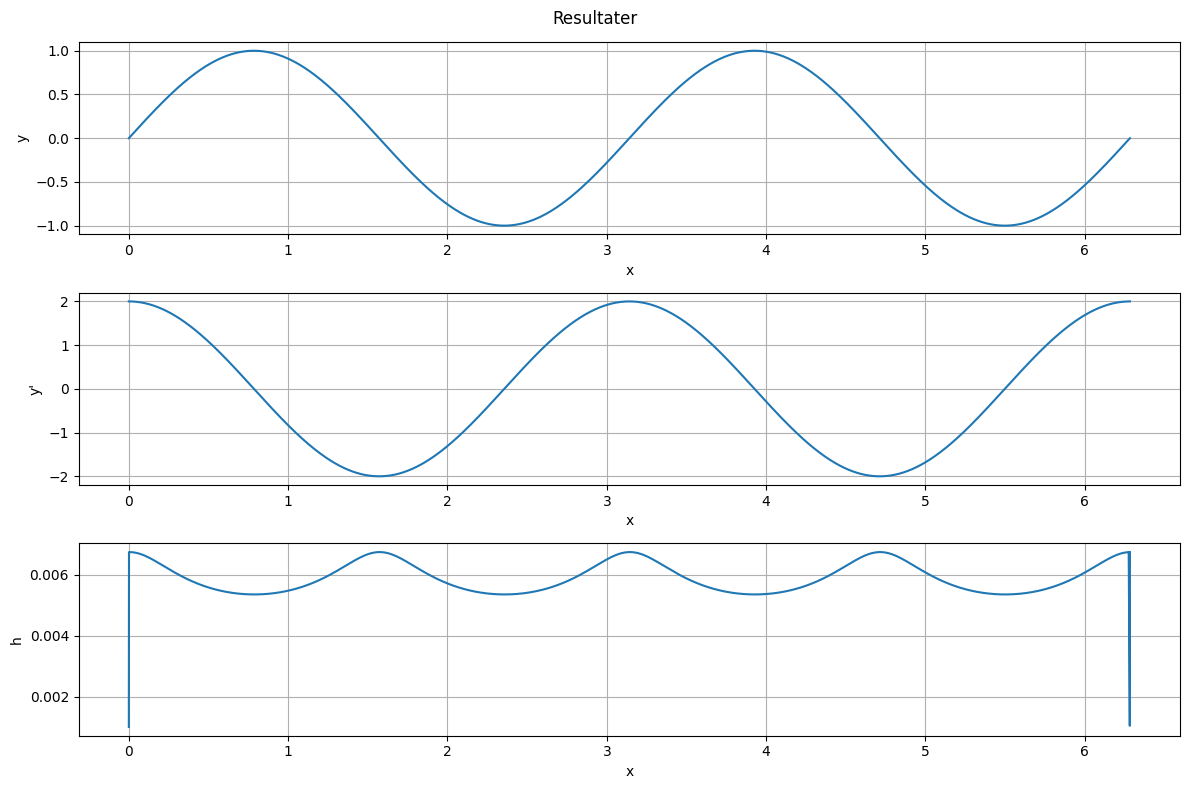

In [27]:
params = Dict.empty(
    key_type=types.unicode_type,
    value_type=types.float64
)

params["x_init"] = 0.0
params["x_end"]= 2*np.pi
params["y_0"] = 0.0
params["y'_0"] = 2.0
params["h_0"] = 1e-3
params["tol"] = 1e-7
params["alpha"] = 0.8


@njit
def diff_system_1(x:float,y:npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """calculates y' and y'' from x, y, y' and the first given differential system.
    
    Args:
    x: the x value
    y: an array (vector) of y and y' value at the given point

    Returns:
    y_der: an array (vector) of the calculated y' and y'' values
    """
    y_der = np.array([y[1], -4*np.sin(2*x)]) 
    return  y_der

@njit
def IVP_solver_1(params: Dict[str,float]) -> tuple[List, List, List, List, int, int]:
    """ solves the first given differential system using rk3 and adjusting step length with rk4
    
        Args:
        params: a dictionary of given parameters

        Returns:
        x_list: a list over all the x values
        y_list: a list over arrays containing all y and y' values from rk3
        z_list: a list over arrays containing all y and y' values from rk4
        h_list: a list over all accepted step lengths
        accepted: the amount of accepted steps
        rejected: the amount of rejected steps
    """
    accepted = 0
    rejected = 0
    x_list = List()
    h_list = List()
    y_list = List.empty_list(types.float64[:])
    z_list = List.empty_list(types.float64[:])
    x_list.append(params["x_init"])
    y_init = np.empty(2, dtype=np.float64)
    y_init[0] = params["y_0"]
    y_init[1] = params["y'_0"]
    y_list.append(y_init)
    h_list.append(params["h_0"])
    k_1 = diff_system_1(x_list[0],y_list[0])

    while x_list[accepted]<params["x_end"]:
        h_list[accepted] = min(h_list[accepted], params["x_end"]-x_list[accepted])
        k_2 = diff_system_1(x_list[accepted]+1/2*h_list[accepted], y_list[accepted] + 1/2*h_list[accepted]*k_1)
        k_3 = diff_system_1(x_list[accepted] + 3/4*h_list[accepted], y_list[accepted] + 3/4*h_list[accepted]*k_2)
        y_new= y_list[accepted] + 1/9*h_list[accepted]*(2*k_1+3*k_2+4*k_3)
        x_new = x_list[accepted] + h_list[accepted]
        k_4 = diff_system_1(x_new,y_new)
        z_new = y_list[accepted] + 1/24*h_list[accepted]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        est = np.sqrt(np.sum((y_new - z_new)**2))
        h_new = (params["alpha"] * h_list[accepted] * (params["tol"]/est)**(1/3))
        if est < params["tol"]:
            accepted+=1
            k_1=k_4
            y_list.append(y_new)
            x_list.append(x_new)
            z_list.append(z_new)
            h_list.append(h_new)
        else: 
            h_list[accepted] = h_new
            rejected +=1
    return x_list, y_list, z_list, h_list, accepted, rejected

x_list, y_list, z_list, h_list, accepted, rejected = IVP_solver_1(params)
y_array = np.stack(y_list)
fig, axes = plt.subplots(3, 1, figsize=[12,8])
plot_solution(ax=axes[0], X=np.array(x_list), Y = y_array[:,0], ylabel = "y")
plot_solution(ax=axes[1], X=np.array(x_list), Y = y_array[:,1], ylabel = "y'")
plot_solution(ax=axes[2], X=np.array(x_list), Y = np.array(h_list), ylabel = "h")
fig.suptitle("Resultater")
plt.tight_layout()
print(np.average(h_list),accepted, rejected)
 

Vi ser at skrittlengden varierer periodisk. Dette kan vi forklare basert på hvor mye krumning vi har i y. Når grafen er tilnærmet linær i punktene 0, pi/2, pi, 3pi/2 og 2pi kan algoritmen ta lange steg uten at feilestimatet blir for stort, men i punktene pi/4, 3pi/4, 5pi/4 og 7*pi/4 har vi mye krumning, Da får man fort feil, og skrittlengden må bli kortere.

## d)

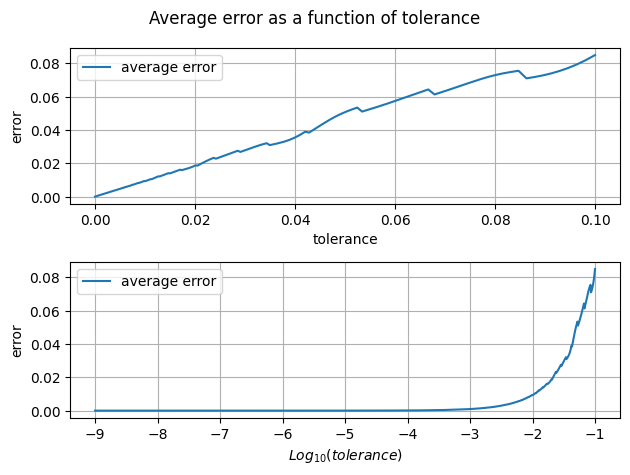

In [ ]:
params["x_init"] = 0.0
params["x_end"]= 2*np.pi
params["y_0"] = 0.0
params["y'_0"] = 2.0
params["h_0"] = 1e-3
params["tol"] = 1e-3
params["alpha"] = 0.8

def solution(x: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """returns the analytic solution y(x) = sin(2x).
    
    Args:
    x: the x values

    Returns:
    y: the analytic solution values at x
    """
    return np.sin(2*x)

exponent_array = np.linspace(1,9,1000)
error_avg_list = List()

for exp in exponent_array:
    params["tol"]=10**(-exp)
    x_list, y_list, _,_,_,_ = IVP_solver_1(params)
    y_array = np.stack(y_list)
    error_avg = np.linalg.norm(solution(np.array(x_list))-y_array[:,0])
    error_avg_list.append(error_avg)
error_avg_array = np.array(error_avg_list)


fig, ax = plt.subplots(2,1)
plot_solution(ax=ax[0], X=10**(-exponent_array), Y = error_avg_array, label = "average error", xlabel="tolerance", ylabel="error")
plot_solution(ax=ax[1], X=-exponent_array, Y = error_avg_array, label = "average error", xlabel="$Log_{10}(tolerance)$", ylabel="error")
fig.suptitle("Average error as a function of tolerance")
fig.tight_layout()

Vi ser at feilen alltid holder seg under toleransen i plottet. Det er en del lokal variasjon, men totalt ser grafen linær ut, dette gir mening ettersom tillatt feil er gitt av toleransen. Vi ser her at en toleranse under 10**-4 fører til svært liten feil.

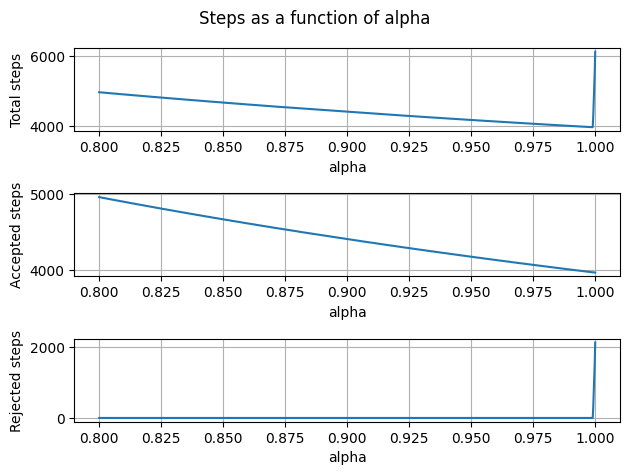

In [29]:


alpha_array = np.linspace(0.8,1,1000)
accepted_list = List()
rejected_list = List()
for alpha in alpha_array:
    params["alpha"] = alpha
    _,_,_,_,accepted,rejected = IVP_solver_1(params)
    accepted_list.append(accepted)
    rejected_list.append(rejected)
accepted_array= np.array(accepted_list)
rejected_array = np.array(rejected_list)
step_array = accepted_array + rejected_array

fig, ax = plt.subplots(3,1)
plot_solution(ax=ax[0], X=alpha_array, Y = step_array, xlabel="alpha", ylabel="Total steps")
plot_solution(ax=ax[1], X=alpha_array, Y = accepted_array, xlabel="alpha", ylabel="Accepted steps")
plot_solution(ax=ax[2], X=alpha_array, Y = rejected_array, xlabel="alpha", ylabel="Rejected steps")
fig.suptitle("Steps as a function of alpha")
fig.tight_layout()


Vi plotter bare alpha fra 0.8 - 1, siden det er sløsete å ha en lavere pessimistfaktor, da dette vil gjøre at antall steg øker betraktelig. Dette er siden skrittlengden reduseres med en faktor alpha, så vi behøver flere steg for å komme til enden.

Vi ser at steg ikke blir avvist før alpha blir veldig nær 1. Problemer oppstår når alpha blir for nærme 1, da feilestimatet vil variere basert på krumningen av grafen, og vi baserer neste h på forrige segment. Da kan vi få en for stor h hvis rk3 estimerer neste segment værre enn forrige. Det er denne forskjellen som fører til at skritt blir avvist, når alpha øker mot 1 vil ikke lenger alpha kompensere for denne variasjonen i feilestimatet. Da får vi avviste steg. 

## e)

In [30]:
def sekant_root_g(
        z_0:float,
        z_1:float, 
        params: Dict[str,float]) -> tuple[float, int]:
    """finds a root of g with the secant method.
    
    Args:
    z_0: the first initial guess
    z_1: the second initial guess
    params: a dictionary of given parameters

    Returns:
    z[n]: the approximated root
    n: the number of iterations
    """
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n]-z[n-1])>params["tol"]:
        z.append((z[n-1]*g(z[n])-z[n]*g(z[n-1]))/(g(z[n])-g(z[n-1])))
        n+=1
    return z[n],n

def g(s: float) -> float:
    """defines the scalar function used in the secant test.
    
    Args:
    s: the input value

    Returns:
    g_s: the function value at s
    """
    return s + np.sin(s) + np.cos(s)

print(sekant_root_g(-20.0,20.0,params))
root = sekant_root_g(-20.0,20.0,params)[0]
print((root + np.sin(root) + np.cos(root))<10**-10)

(-0.45662470456763077, 7)
True


Her ser vi at sekantmetoden finner korrekt nullpunkt for funksjonen vår. vi får g(root) = 0

## f)

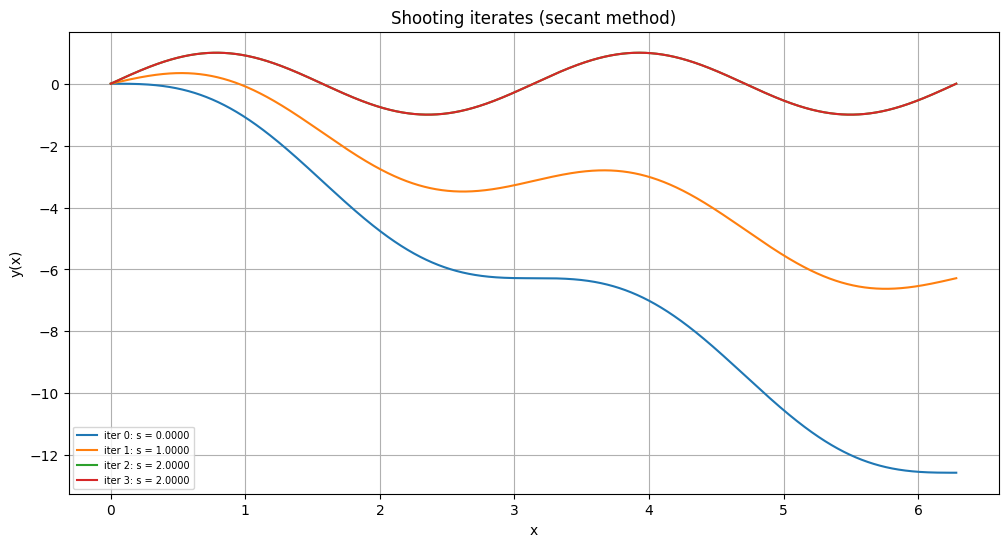

In [32]:

def shoot_1(s: float, params: Dict[str,float]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """solves the first ivp for a guessed initial slope s.
    
    Args:
    s: the guessed initial slope
    params: a dictionary of given parameters

    Returns:
    x_array: an array of x values
    y_array: an array of y and y' values
    """
    params["y'_0"] = s
    x_list, y_list,_,_,_,_ = IVP_solver_1(params=params)
    y_array = np.stack(y_list)
    x_array = np.array(x_list)
    return x_array, y_array

def F_1( s: float, params: Dict[str,float]) -> float:
    """shooting residual: y(xend) - yb.
    
    Args:
    s: the guessed initial slope
    params: a dictionary of given parameters

    Returns:
    error: the error in the y values at the boundary 
    """
    _, Y = shoot_1(s, params)
    return Y[-1, 0] - 0

def sekant_root_1(z_0:float, z_1:float, params: Dict[str,float]) -> tuple[float, int]:
    """finds the shooting slope for the first system with the secant method.
    
    Args:
    z_0: the first initial guess
    z_1: the second initial guess
    params: a dictionary of given parameters

    Returns:
    z[n]: the approximated shooting slope
    n: the number of iterations
    """
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n-1]-z[n])>params["tol"]:
        z.append((z[n-1]*F_1(z[n],params)-z[n]*F_1(z[n-1],params))/(F_1(z[n],params)-F_1(z[n-1],params)))
        n+=1
    return z[n],n

def shooting_method_1(params: Dict[str,float], s_init: npt.NDArray[np.float64],shooting_tol:float) -> tuple[List, List, List]:
    """runs the shooting method for the first boundary value problem.
    
    Args:
    params: a dictionary of given parameters
    s_init: an array of the two initial slope guesses
    shooting_tol: the tolerance for the shooting iteration

    Returns:
    s_list: a list of slope guesses from all iterations
    x_arrays: a list of x arrays from all iterations
    y_arrays: a list of y arrays from all iterations
    """
    x_arrays = List()
    y_arrays = List()
    s_list = List()
    s_list.append(s_init[0])
    s_list.append(s_init[1])
    for s in s_init:
        x_array, y_array = shoot_1(s, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
    n=1
    while abs(s_list[n]-s_list[n-1]) >= shooting_tol:
        s_new,_ = sekant_root_1(s_list[n-1],s_list[n],params)
        s_list.append(s_new)
        x_array, y_array = shoot_1(s_new, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
        n+=1
    return s_list, x_arrays, y_arrays
s_list, x_arrays, y_arrays = shooting_method_1(params,np.array([0.0,1.0]),10**-10)

fig, ax = plt.subplots( figsize=(12,6))
for i in range(len(x_arrays)):
    plot_solution(ax=ax, X=x_arrays[i], Y = y_arrays[i][0:,0], label=f"iter {i}: s = {s_list[i]:.4f}")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("Shooting iterates (secant method)")
ax.grid(True)
ax.legend(fontsize=7)
plt.show()

Vi ser at allerede første skyting etter de initielle s-verdiene er korrekt ned til minst 4 desimaler, og metoden har funnet et stabilt svar umiddelbart.

## g)

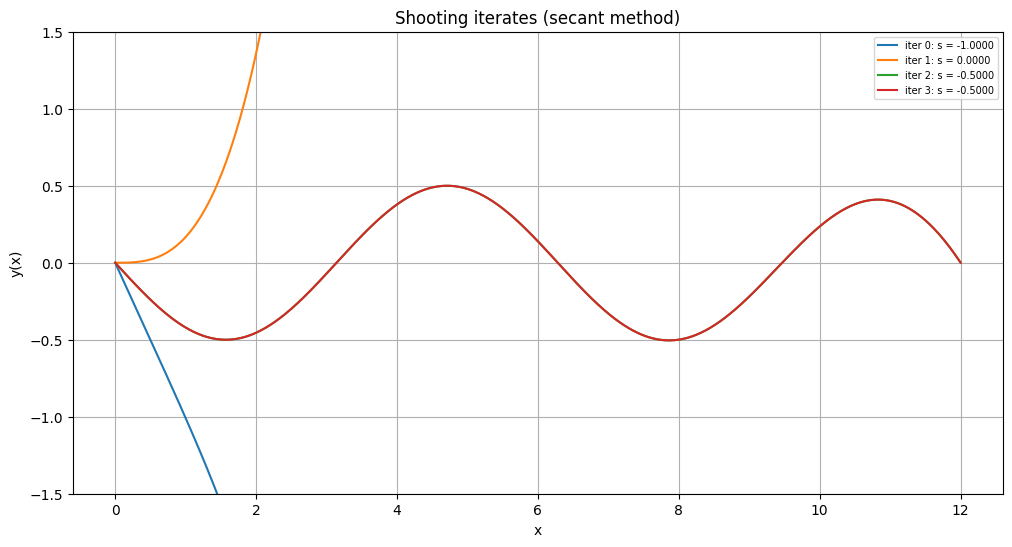

In [34]:
params["x_init"] = 0.0
params["x_end"]= 12.0
params["y_0"] = 0.0
params["y'_0"] = 0.0
params["h_0"] = 1e-3
params["tol"] = 1e-7
params["alpha"] = 0.8

@njit
def diff_system_2(x:float, y:npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """calculates y' and y'' from x, y, y' and the second given differential system.
    
    Args:
    x: the x value
    y: an array (vector) of y and y' value at the given point

    Returns:
    y_der: an array (vector) of the calculated y' and y'' values
    """
    return np.array([y[1], y[0] + np.sin(x)])

@njit
def IVP_solver_2(params: Dict[str,float]) -> tuple[List, List, List, List, int, int]:
    """ solves the second given differential system using rk3 and adjusting step length with rk4
    
        Args:
        params: a dictionary of given parameters

        Returns:
        x_list: a list over all the x values
        y_list: a list over arrays containing all y and y' values from rk3
        z_list: a list over arrays containing all y and y' values from rk4
        h_list: a list over all accepted step lengths
        accepted: the amount of accepted steps
        rejected: the amount of rejected steps
    """
    accepted = 0
    rejected = 0
    x_list = List()
    h_list = List()
    y_list = List.empty_list(types.float64[:])
    z_list = List.empty_list(types.float64[:])
    x_list.append(params["x_init"])
    y_init = np.empty(2, dtype=np.float64)
    y_init[0] = params["y_0"]
    y_init[1] = params["y'_0"]
    y_list.append(y_init)
    h_list.append(params["h_0"])
    k_1 = diff_system_2(x_list[0],y_list[0])

    while x_list[accepted]<params["x_end"]:
        h_list[accepted] = min(h_list[accepted], params["x_end"]-x_list[accepted])
        k_2 = diff_system_2(x_list[accepted]+1/2*h_list[accepted], y_list[accepted] + 1/2*h_list[accepted]*k_1)
        k_3 = diff_system_2(x_list[accepted] + 3/4*h_list[accepted], y_list[accepted] + 3/4*h_list[accepted]*k_2)
        y_new= y_list[accepted] + 1/9*h_list[accepted]*(2*k_1+3*k_2+4*k_3)
        x_new = x_list[accepted] + h_list[accepted]
        k_4 = diff_system_2(x_new,y_new)
        z_new = y_list[accepted] + 1/24*h_list[accepted]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        est = np.sqrt(np.sum((y_new - z_new)**2))
        h_new = (params["alpha"] * h_list[accepted] * (params["tol"]/est)**(1/3))
        if est < params["tol"]:
            accepted+=1
            k_1=k_4
            y_list.append(y_new)
            x_list.append(x_new)
            z_list.append(z_new)
            h_list.append(h_new)
        else: 
            h_list[accepted] = h_new
            rejected +=1
    return x_list, y_list, z_list, h_list, accepted, rejected


def shoot_2(s: float, params: Dict[str,float]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """solves the second ivp for a guessed initial slope s.
    
    Args:
    s: the guessed initial slope
    params: a dictionary of given parameters

    Returns:
    x_array: an array of x values
    y_array: an array of y and y' values
    """
    params["y'_0"] = s
    x_list, y_list,_,_,_,_ = IVP_solver_2(params)
    y_array = np.stack(y_list)
    x_array = np.array(x_list)
    return x_array, y_array


def F_2( s: float, params) -> float:
    """shooting residual: y(xend) - yb.
    
    Args:
    s: the guessed initial slope
    params: a dictionary of given parameters

    Returns:
    error: the error in the y values at the boundary 
    """
    _, Y = shoot_2(s, params)
    return Y[-1, 0]


def sekant_root_2(z_0:float, z_1:float, params: Dict[str,float]) -> tuple[float, int]:
    """finds the shooting slope for the second system with the secant method.
    
    Args:
    z_0: the first initial guess
    z_1: the second initial guess
    params: a dictionary of given parameters

    Returns:
    z[n]: the approximated shooting slope
    n: the number of iterations
    """
    z = List()
    z.append(z_0)
    z.append(z_1)
    n=1
    while abs(z[n-1]-z[n])>params["tol"]:
        z.append((z[n-1]*F_2(z[n],params)-z[n]*F_2(z[n-1],params))/(F_2(z[n],params)-F_2(z[n-1],params)))
        n+=1
    return z[n],n

def shooting_method_2(params, s_init: npt.NDArray[np.float64],shooting_tol) -> tuple[List, List, List]:
    """runs the shooting method for the second boundary value problem.
    
    Args:
    params: a dictionary of given parameters
    s_init: an array of the two initial slope guesses
    shooting_tol: the tolerance for the shooting iteration

    Returns:
    s_list: a list of slope guesses from all iterations
    x_arrays: a list of x arrays from all iterations
    y_arrays: a list of y arrays from all iterations
    """
    x_arrays = List()
    y_arrays = List()
    s_list = List()
    s_list.append(s_init[0])
    s_list.append(s_init[1])
    for s in s_init:
        x_array, y_array = shoot_2(s, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
    n=1
    while abs(s_list[n]-s_list[n-1]) >= shooting_tol:
        s_new,_ = sekant_root_2(s_list[n-1],s_list[n],params)
        s_list.append(s_new)
        x_array, y_array = shoot_2(s_new, params)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
        n+=1
    return s_list, x_arrays, y_arrays
s_list, x_arrays, y_arrays =shooting_method_2(params,np.array([-1.0,0.0]),10**-7)
fig, ax = plt.subplots( figsize=(12,6))
for i in range(len(x_arrays)):
    plot_solution(ax=ax, X=x_arrays[i], Y = y_arrays[i][0:,0], label=f"iter {i}: s = {s_list[i]:.4f}")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_ylim(-1.5, 1.5)
ax.set_title("Shooting iterates (secant method)")
ax.grid(True)
ax.legend(fontsize=7)
plt.show()

Her ser vi veldig lingende situasjon som i oppgave 1f, med umiddelbar konvergens rundt korrekt svar.

## h)


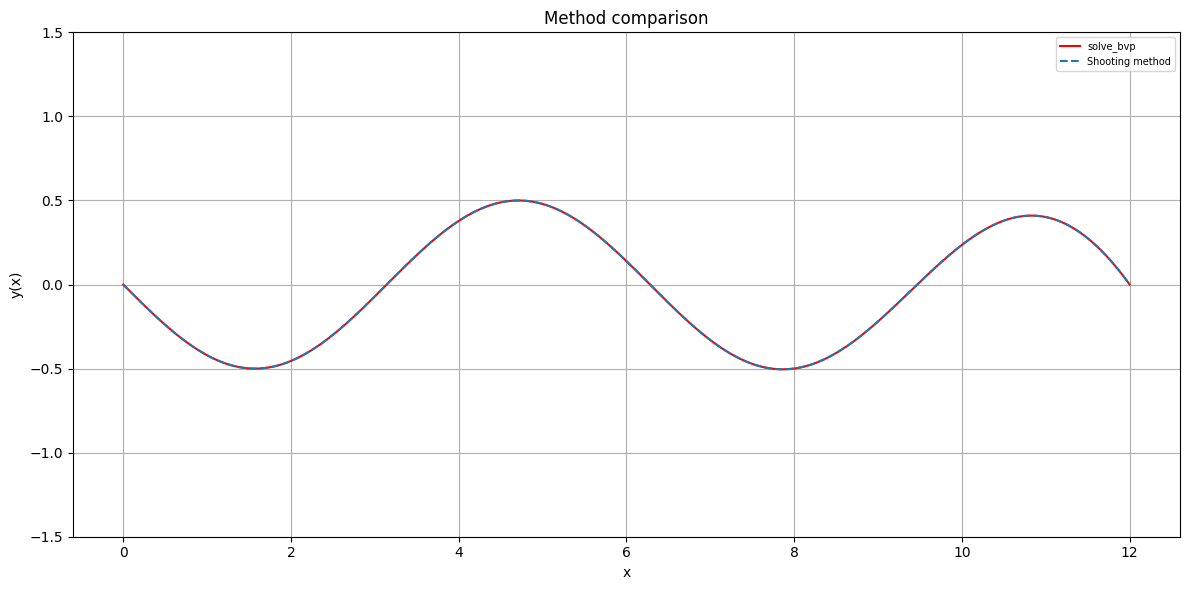

In [35]:
def diff_system_2_plain(x:float, y:npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """defines the second system in the format solve_bvp expects.
    
    Args:
    x: the x value
    y: an array of y and y' values

    Returns:
    y_der: an array of the calculated y' and y'' values
    """
    return np.array([y[1], y[0] + np.sin(x)])

s_list, x_arrays, y_arrays =shooting_method_2(params,np.array([-1.0,0.0]),10**-7)

def bc_2(y_a:npt.NDArray[np.float64],y_b:npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """defines the boundary conditions for solve_bvp.
    
    Args:
    y_a: the solution vector at the left boundary
    y_b: the solution vector at the right boundary

    Returns:
    bc: an array describing the boundary residuals
    """
    return np.array([y_a[0],y_b[0]])

x_0 = np.linspace(params["x_init"],params["x_end"],100)
solution = solve_bvp(diff_system_2_plain, bc_2, x_0, np.zeros((2, x_0.size)))
Y_sol = solution.sol(x_arrays[-1])

fig, ax = plt.subplots(figsize=(12, 6))
plot_solution(ax, x_arrays[-1], Y_sol[0], label="solve_bvp", color="red")
plot_solution(ax, x_arrays[-1],  y_arrays[-1][:,0], label="Shooting method", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("Method comparison")
ax.set_ylim(-1.5, 1.5)
ax.grid(True)
ax.legend(fontsize=7)
plt.tight_layout()


Metodene ser ut til å produsere identiske svar, dette tyder at programmet vårt er korrekt.

C:\Users\Frederik\AppData\Local\Temp\ipykernel_18380\3266163162.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


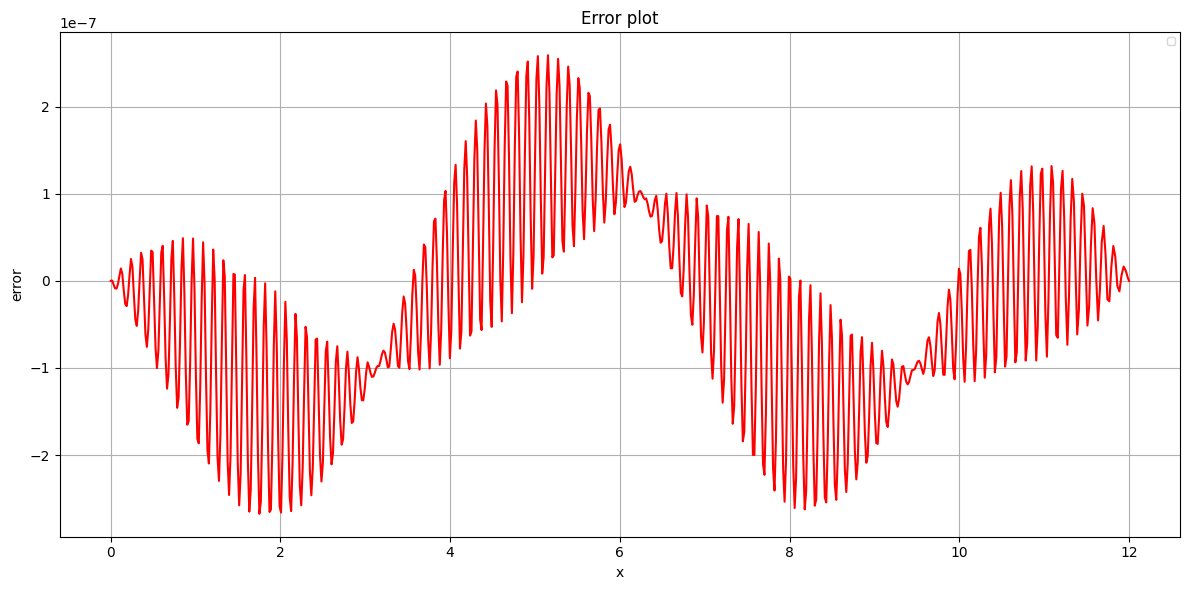

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_solution(ax, x_arrays[-1], y_arrays[-1][:,0] - Y_sol[0], color="red")
ax.set_xlabel("x")
ax.set_ylabel("error")
ax.set_title("Error plot")
ax.grid(True)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Her ser vi at feilen i metoden vår er på størrelses orden med toleransen vår. Grunnen til at feilen er større en toleransen er trolig at vi har en toleranse for IVP-løseren, og en seperat toleranse for skytemetoden.

In [37]:
for i in range(300000):
    Y_sol = solution.sol(x_arrays[-1])

In [38]:
for i in range(10):    
    s_list, x_arrays, y_arrays =shooting_method_2(params,np.array([-1.0,0.0]),10**-7)

Vi observerer stor forskjell i kjøretid mellom metodene. Vår metode klarer å kjøre 10 ganger på noen sekunder, mens solve_bvp kjører 300 000 ganger på samme tid. Det er klart at solve_bvp er flere størrelsesordener mer effektivt enn vår løsning, og derfor et bedre valg for praktisk bruk.

# Oppgave 2

In [1]:
import numpy as np

import numpy.typing as npt
from collections.abc import Callable
from typing import Literal, cast

from pathlib import Path

import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, simpson

##### Bruk av np.einsum i prosjektet

`np.einsum` er en funksjon som benytter Einstein-summasjonskonvensjon til å utføre komplekse array-operasjoner, i vårt tilfelle spesifikt matrisemultiplikasjon og trace. Mens `numpy.matmul` (som kan forkortes til `@`) er svært godt optimalisert ved hjelp av BLAS (Basic Linear Algebra Subprograms), blir `np.einsum` særlig nyttig når vi jobber med høyeredimensjonale arrays. Den tillater oss å skrive operasjoner mer kompakt, unngår unødvendige mellomregninger og allokeringer av midlertidige (og potensielt store) arrays i minnet. Når vi i tillegg inkluderer argumentet `optimize=True` kan `np.einsum` også selv finne den mest effektive sammentrekningsrekkefølgen for operasjonene våre.

##### Vektorisering for å unngå Python-løkker

I tillegg til fordelene med `np.einsum`, har vi vektorisert utregningene våre. Ved å samle dataene i store, flerdimensjonale arrays dimensjonert som $(2, 2, N_x)$, kan vi regne ut tilstanden til hele systemet på en gang. Dette lar Numpy utføre iterasjonene direkte i kompilert kode, noe som fjerne ytelsestap vi ville fått ved å iterere over punktene med for-løkker.

**Under følger implementasjon av de to funksjonene vi kommer til å bruke**

In [2]:
def bmm(
    A: npt.NDArray[np.complex128], 
    B: npt.NDArray[np.complex128],
) -> npt.NDArray[np.complex128]:
    """Matrix multiplication performed in batches using np.einsum
    Args:
        A (npt.NDArray[np.complex128]): Matrix 1, either (2, 2) or (2, 2, N_x)
        B (npt.NDArray[np.complex128]): Matrix 2, either (2, 2) or (2, 2, N_x)
    Returns:
        npt.NDArray[np.complex128]: Product of the matrices
    """

    if A.ndim == 2 and B.ndim == 2:
        return A @ B
    if A.ndim == 2 and B.ndim == 3:
        return np.einsum('ij,jkl->ikl', A, B, optimize=True)
    if A.ndim == 3 and B.ndim == 3:
        return np.einsum('ijk,jlk->ilk', A, B, optimize=True)
    
    raise ValueError(f"Received unknown shapes: {A.shape}, {B.shape}")


def tr(
    A: npt.NDArray[np.complex128]
) -> np.complex128 | npt.NDArray[np.complex128]:
    """Computes the trace of a matrix with np.einsum
    Args:
        A (npt.NDArray[np.complex128]): Matrix to be traced
    Returns:
        np.complex128 | npt.NDArray[np.complex128]: Trace of matrix A, either (2, 2) or (2, 2, N_x)
    """

    if A.ndim == 2:
        return np.einsum('...ii', A, optimize=True)
    
    return np.einsum('iik->k', A, optimize=True)

## a)

In [3]:
def complex_to_real(matrix: npt.NDArray[np.complex128]) -> npt.NDArray[np.float64]:
    """Transforms real matrix to flattened real vector

    Args:
        matrix (npt.NDArray[np.complex128]): complex matrix

    Returns:
        npt.NDArray[np.float64]: flattened real vector of the form v = (real, imag)
    """
    single = matrix.ndim == 2
    if single:
        matrix = matrix[..., np.newaxis]

    N_x = matrix.shape[-1]
    real_arr = np.real(matrix).reshape(-1, N_x)
    im_arr = np.imag(matrix).reshape(-1, N_x)

    result = np.concatenate([real_arr, im_arr], axis=0, dtype=np.float64)

    if single: 
        return result.squeeze(axis=-1)
    else:
        return result

def real_to_complex(
    vec: npt.NDArray[np.float64], 
    matrix_shape: tuple[int, ...] = (2, 2),
    ) -> npt.NDArray[np.complex128]:
    """Transforms real flattened vector into complex matrix

    Args:
        vec (npt.NDArray[np.float64]): real flattened vector of the form v = (real, imag)
        matrix_shape (tuple[int, ...], optional): Shape of matrix to be returned. Defaults to (2, 2).

    Raises:
        ValueError: vec must be of even size, to have as many complex parts as real

    Returns:
        npt.NDArray[np.complex128]: complex matrix
    """
    single = vec.ndim == 1

    if single:
        vec = vec[:, np.newaxis]

    if vec.shape[0] % 2 != 0:
        raise ValueError("Vec must be of even size")

    n = vec.shape[0]//2
    real_arr = vec[:n]
    im_arr = vec[n:]

    N_x = vec.shape[1]
    result = (real_arr + 1j * im_arr).reshape(*matrix_shape, N_x)

    if single: 
        return result.squeeze(axis=-1)
    else:
        return result

For funksjoner med invers, som i a), b) og c), kan vi se på funksjonene som $f: V \rightarrow W$, $g: W \rightarrow V$ der V og W er to vektorrom. Konstruerer vektorer i V og W og bekrefter at $f(g(w)) = w$, $g(f(v)) = v$ for å sjekke at de er inverser til hverandre.

I dette tilfellet er $\text{complex\_to\_real}: \mathbb{C}^{n \times n} \rightarrow \mathbb{R}^{2 n^2}$ og $\text{real\_to\_complex}: \mathbb{R}^{2 n^2} -> \mathbb{C}^{n \times n}$ der $n = 2$ for oppgaven.

In [4]:
real_vec = np.array([1, -2, 3, 0, 4, -1, 2, 5])
complex_vec = np.array([[2 + 3j, -1 + 4j], [0 - 2j, 5 + 1j]])

real_transf_vec = complex_to_real(real_to_complex(real_vec))
complex_transf_vec = real_to_complex(complex_to_real(complex_vec))

print(f'real -> complex -> real: {np.array_equal(real_transf_vec, real_vec)}')
print(f'complex -> real -> complex: {np.array_equal(complex_transf_vec, complex_vec)}')

real -> complex -> real: True
complex -> real -> complex: True


Noice:)

## b)

In [5]:
def expand_vec(vec_arr: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Expands array of real vectors (matrix) to one vector

    Args:
        vec_arr (npt.NDArray[np.float64]): array of vectors to expand

    Returns:
        npt.NDArray[np.float64]: expanded vector
    """
    
    return np.concat(vec_arr, axis = 0, dtype = np.float64)

def reshape_vec(
    vec: npt.NDArray[np.float64], 
    vec_size: int = 8,
    ) -> npt.NDArray[np.float64]:
    """Creates component vectors from one vector
    
    Args:
        vec (npt.NDArray[np.float64]): vector to be reshaped.
        vec_size (int, optional): desired size of component vectors. Defaults to 8

    Raises:
        ValueError: Vector must be divisible by desired vector component length

    Returns:
        npt.NDArray[np.float64]: matrix where each row is component vector of original vector
    """
    if len(vec) % vec_size != 0:
        raise ValueError("Vec must be divisible by vec_size")

    return vec.reshape(-1, vec_size)


I dette tilfellet er $\text{expand\_vec}: (\mathbb{R}^{m \times n}) \rightarrow \mathbb{R}^{mn}$ og $\text{reshape\_vec}\mathbb{R}^{mn} \rightarrow \mathbb{R}^{m \times n}$, der $m = 4$ og $n = 8$ for oppgaven spesifikt.

In [6]:
matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8],
    [9, 10, 11, 12, 13, 14, 15, 16],
    [17, 18, 19, 20, 21, 22, 23, 24],
    [25, 26, 27, 28, 29, 30, 31, 32]
], dtype=np.float64)

vec_expanded = np.array([
    3, -1, 4, 1, 5, 9, 2, 6,
    5, 3, 5, 8, 9, 7, 9, 3,
    2, 3, 8, 4, 6, 2, 6, 4,
    3, 3, 8, 3, 2, 7, 9, 5
], dtype=np.float64)

transf_matrix = reshape_vec(expand_vec(matrix))
transf_expand_vec = expand_vec(reshape_vec(vec_expanded))

print(f'Matrix -> expanded -> matrix: {np.array_equal(transf_matrix, matrix)}')
print(f'Expanded -> matrix -> expanded: {np.array_equal(transf_expand_vec, vec_expanded)}')


Matrix -> expanded -> matrix: True
Expanded -> matrix -> expanded: True


## c)

In [7]:
def usadel_matrix_to_vec(
    gamma: npt.NDArray[np.complex128], 
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
    ) -> npt.NDArray[np.float64]:
    """Expands the four usadel matrices into one real vector

    Args:
        gamma (npt.NDArray[np.complex128]): gamma matrix
        gamma_tilde (npt.NDArray[np.complex128]): gamma tilde matrix
        w (npt.NDArray[np.complex128]): w matrix
        w_tilde (npt.NDArray[np.complex128]): w tilde matrix

    Raises:
        ValueError: all matrices should be of shape (2,2)

    Returns:
        npt.NDArray[np.float64]: expanded real vector
    """
    single = gamma.ndim == 2

    if single:
        gamma, gamma_tilde, w, w_tilde = (
            m[..., np.newaxis] for m in [gamma, gamma_tilde, w, w_tilde]
        )

    if not (gamma.shape == gamma_tilde.shape == w.shape == w_tilde.shape):
        raise ValueError("All matrices must have the same shape")

    result = np.stack([
        complex_to_real(gamma),
        complex_to_real(gamma_tilde),
        complex_to_real(w),
        complex_to_real(w_tilde)
    ], axis=0).reshape(-1, gamma.shape[-1]) 

    if single:
        return result.squeeze(axis=-1)
    else:
        return result
    
def vec_to_usadel_matrix(
    vec: npt.NDArray[np.float64],
    matrix_shape: tuple[int, ...] = (2, 2),
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Transform vector into the usadel matrices, gamma, gamma_tilde, w, w_tilde

    Args:
        vec (npt.NDArray[np.float64]): vector to be transformed
        matrix_shape (tuple[int, ...], optional): shape of usadel matrices. Defaults to (2, 2)

    Raises:
        ValueError: Matrix_shape should be so that vec can be divided into equally shaped matrices

    Returns:
        tuple[npt.NDArray[np.complex128], npt.NDArray[np.complex128], npt.NDArray[np.complex128], npt.NDArray[np.complex128]]:  gamma, gamma_tilde, w, w_tilde
    """
    single = vec.ndim == 1

    if single:
        vec = vec[:, np.newaxis]

    component_len = 2 * np.prod(matrix_shape)
    expected_len = 4 * component_len
    
    N_x = vec.shape[1]

    if vec.shape[0] != expected_len:
        raise ValueError("vector size and matrix_shape not compatible")

    blocks = vec.reshape(4, component_len, N_x)
    
    gamma = real_to_complex(blocks[0], matrix_shape)
    gamma_tilde = real_to_complex(blocks[1], matrix_shape)
    w = real_to_complex(blocks[2], matrix_shape)
    w_tilde = real_to_complex(blocks[3], matrix_shape)

    if single:
        return (
            gamma.squeeze(axis = -1),
            gamma_tilde.squeeze(axis = -1),
            w.squeeze(axis = -1),
            w_tilde.squeeze(axis = -1)
        )
    return gamma, gamma_tilde, w, w_tilde


Her er $\text{usadel\_matrix\_to\_vec}: (\mathbb{C^{2 \times 2}})^4 \rightarrow \mathbb{R}^{32}$ og $\text{vec\_to\_usadel\_random}: \mathbb{R}^{32} \rightarrow (\mathbb{C}^{2 \times 2})^4$.

In [8]:
gamma = np.array([
    [1 + 2j, 3 + 4j],
    [5 + 6j, 7 + 8j]
], dtype=np.complex128)

gamma_tilde = np.array([
    [2 - 1j, 4 - 3j],
    [6 - 5j, 8 - 7j]
], dtype=np.complex128)

w = np.array([
    [0 + 1j, 1 + 0j],
    [2 + 3j, 4 + 5j]
], dtype=np.complex128)

w_tilde = np.array([
    [9 + 0j, 8 + 1j],
    [7 + 2j, 6 + 3j]
], dtype=np.complex128)

vec = vec = np.array([
    1, 2, 3, 4, 5, 6, 7, 8,
    9, 10, 11, 12, 13, 14, 15, 16,
    17, 18, 19, 20, 21, 22, 23, 24,
    25, 26, 27, 28, 29, 30, 31, 32
], dtype=np.float64)

gamma_transf, gamma_tilde_transf, w_transf, w_tilde_transf = vec_to_usadel_matrix(usadel_matrix_to_vec(gamma, gamma_tilde, w, w_tilde))
transf_vec = usadel_matrix_to_vec(*vec_to_usadel_matrix(vec))


print(f'Matrix -> vec -> matrix: {np.array_equal(gamma, gamma_transf) and np.array_equal(gamma_tilde, gamma_tilde_transf) and np.array_equal(w, w_transf) and np.array_equal(w_tilde, w_tilde_transf)}')
print(f'Vec -> matrix -> vec: {np.array_equal(transf_vec, vec)}')

Matrix -> vec -> matrix: True
Vec -> matrix -> vec: True


## d)

In [9]:
def N_fun(
    gamma: npt.NDArray[np.complex128], 
    gamma_tilde: npt.NDArray[np.complex128],
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
]:
    """Calculates the Riccati normalization matrices

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Raises:
        ValueError: gamma and gamma_tilde should be of size (2,2)

    Returns:
        tuple[ npt.NDArray[np.complex128], npt.NDArray[np.complex128] ]: normalization matrix, conjugate normalization matrix
    """
    single = gamma.ndim == 2

    if single:
        gamma = gamma[..., np.newaxis]
        gamma_tilde = gamma_tilde[..., np.newaxis]

    if gamma.shape[:2] != (2, 2) or gamma.shape != gamma_tilde.shape:
        raise ValueError("gamma and gamma_tilde should have shape (2,2) or (2,2,N_x)")

    N_x = gamma.shape[-1]
    I = np.eye(2, dtype=np.complex128)[..., np.newaxis] * np.ones(N_x)

    A = np.moveaxis(I - bmm(gamma, gamma_tilde), -1, 0)
    B = np.moveaxis(I - bmm(gamma_tilde, gamma), -1, 0)

    N = cast(npt.NDArray[np.complex128], np.moveaxis(np.linalg.inv(A), 0, -1))
    N_tilde = cast(npt.NDArray[np.complex128], np.moveaxis(np.linalg.inv(B), 0, -1))

    if single:
        return N.squeeze(axis=-1), N_tilde.squeeze(axis=-1)
    else:
        return N, N_tilde

def N_deriv_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
    ) -> tuple[
    npt.NDArray[np.complex128],
    npt.NDArray[np.complex128],
]:
    """Calculates the derivative of the normalization matrix

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        tuple[ npt.NDArray[np.complex128], npt.NDArray[np.complex128] ]: d_x N, d_x N_tilde
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)

    d_N = bmm(bmm(N, bmm(w, gamma_tilde) + bmm(gamma, w_tilde)), N)
    d_N_tilde = bmm(bmm(N_tilde, bmm(w_tilde, gamma) + bmm(gamma_tilde, w)), N_tilde)

    return d_N, d_N_tilde  

def vec_deriv_vectorized(
    vec: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
) -> npt.NDArray[np.float64]:
    """Calculates derivative of a batch of flattened vectors
    Args:
        vec (npt.NDArray[np.float64]): Flattened vector (n_flat, N_x)
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
    Returns:
        npt.NDArray[np.float64]: derivative of the batch of flattened vectors
    """

    gamma, gamma_tilde, w, w_tilde = vec_to_usadel_matrix(vec)

    N, N_tilde = N_fun(gamma, gamma_tilde)

    d_gamma = w
    d_gamma_tilde = w_tilde
    d_w = (-2j * (epsilon + 1j * delta) * gamma - 2 * bmm(bmm(bmm(w, N_tilde), gamma_tilde), w))
    d_w_tilde = (-2j * (epsilon + 1j * delta) * gamma_tilde - 2 * bmm(bmm(bmm(w_tilde, N), gamma), w_tilde))

    return usadel_matrix_to_vec(d_gamma, d_gamma_tilde, d_w, d_w_tilde)

## e)

In [10]:
def make_diff_system(
    epsilon: float,
    delta: float,
    ) -> Callable[
    [npt.NDArray[np.float64], npt.NDArray[np.float64]],
    npt.NDArray[np.float64]
]:
    """Crates diff system function for bvp solver, dependent on necessary physical parameters

    Args:
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift

    Returns:
        Callable[ [npt.NDArray[np.float64], npt.NDArray[np.float64]], npt.NDArray[np.float64] ]: diff_system function
    """
    def diff_system(
        x: npt.NDArray[np.float64], 
        vec: npt.NDArray[np.float64]
        ) -> npt.NDArray[np.float64]:
        return vec_deriv_vectorized(vec, epsilon, delta)
    
    return diff_system

## f + i)

Istedenfor å lage to bc funksjoner for metall uten superleder, og koblet sammen med to superledere, definerte vi Riccati_superconductor for å gi matrisene, og lot bc funksjonen ta inn en bool Superconductor (True/False) istedenfor. Derfor er f og i løst i samme funksjon, og vi avviker litt fra oppgave rekkefølgen.

In [11]:
def Riccati_superconductor(
    epsilon: float,
    delta: float,
    phi_L: float,
    phi_R: float,
) -> npt.NDArray[np.complex128]:
    """Calculates Riccati boundary matrices for normal metal insterfaced with two superconductors

    Args:
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
        phi_L (float): Left superconducting phase. 
        phi_R (float): Right superconducting phase. 
        
    Returns:
        npt.NDArray[np.complex128]: Array of matrices gamma_L, gamma_L_tilde, gamma_R, gamma_R_tilde respectively
    """
    
    vartheta = lambda sigma, epsilon = epsilon, delta = delta: np.atanh(sigma/(epsilon + 1j * delta))
    s = lambda sigma, epsilon = epsilon, delta = delta: np.sinh(vartheta(sigma, epsilon, delta))
    c = lambda sigma, epsilon = epsilon, delta = delta: np.cosh(vartheta(sigma, epsilon, delta))

    #1 for positive (e.g. s_+), -1 for negative (e.g. s_-)
    gamma_L = np.block([[0, s(1) / (1 + c(1))], [s(-1)/(1 + c(-1)), 0]])* np.exp(1j * phi_L)
    gamma_L_tilde = np.block([[0, s(-1) / (1 + c(-1))], [s(1) / (1 + c(1)), 0]]) * np.exp(-1j * phi_L)
    gamma_R = np.block([[0, s(1) / (1 + c(1))], [s(-1)/(1 + c(-1)), 0]])* np.exp(1j * phi_R)
    gamma_R_tilde = np.block([[0, s(-1) / (1 + c(-1))], [s(1) / (1 + c(1)), 0]]) * np.exp(-1j * phi_R)
    
    return np.array([gamma_L, gamma_L_tilde, gamma_R, gamma_R_tilde])

def make_bc(
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> Callable[
    [npt.NDArray[np.float64], npt.NDArray[np.float64]],
    npt.NDArray[np.float64]
]:
    """Creates boundary condition function for bvp_solver

    Args:
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        Callable[ [npt.NDArray[np.float64], npt.NDArray[np.float64]], npt.NDArray[np.float64] ]: bc function
    """
    def bc(
        v_left: npt.NDArray[np.float64], 
        v_right: npt.NDArray[np.float64]
    ) -> npt.NDArray[np.float64]:
        l_gamma, l_gamma_tilde, l_w, l_w_tilde = vec_to_usadel_matrix(v_left)
        r_gamma, r_gamma_tilde, r_w, r_w_tilde = vec_to_usadel_matrix(v_right)
        
        if superconductor:
            gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = tuple(Riccati_superconductor(epsilon, delta, phi_L, phi_R))
        else:
            gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = (
                np.zeros_like(l_gamma, dtype = np.complex128), 
                np.zeros_like(l_gamma_tilde, dtype = np.complex128), 
                np.zeros_like(r_gamma, dtype = np.complex128), 
                np.zeros_like(r_gamma_tilde, dtype = np.complex128)
                )

        N_L, N_tilde_L = N_fun(gamma_L, gamma_tilde_L)
        N_R, N_tilde_R = N_fun(gamma_R, gamma_tilde_R)
        I = np.eye(2, dtype=np.complex128)

        l_w_boundary = (l_w + 1/(zeta * l) * bmm(bmm((I - bmm(l_gamma, gamma_tilde_L)), N_L), (gamma_L - l_gamma)))
        l_w_tilde_boundary = (l_w_tilde + 1/(zeta * l) * bmm(bmm((I - bmm(l_gamma_tilde, gamma_L)), N_tilde_L), (gamma_tilde_L - l_gamma_tilde)))
        r_w_boundary = (r_w - 1/(zeta * l) * bmm(bmm((I - bmm(r_gamma, gamma_tilde_R)), N_R), (gamma_R - r_gamma)))
        r_w_tilde_boundary = (r_w_tilde - 1/(zeta * l) * bmm(bmm((I - bmm(r_gamma_tilde, gamma_R)), N_tilde_R), (gamma_tilde_R - r_gamma_tilde)))
        
        return usadel_matrix_to_vec(l_w_boundary, l_w_tilde_boundary, r_w_boundary, r_w_tilde_boundary)
    
    return bc

## g)

In [12]:
def usadel_solver(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Calcualtes the Riccati parameters for given x and y

    Args:
        x (np.NDArray[np.float64]): Array to find solution on
        y (np.NDARray[np.float64]): Initial guess
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        tuple[npt.NDArray[
            np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            ]: Arrays of values for gamma, gamma_tilde, w, w_tilde arrays at all x positions, sol
    """
    solution = solve_bvp(
        make_diff_system(epsilon, delta),
        make_bc(epsilon, delta, zeta, l, phi_L, phi_R, superconductor),
        x, y
    )  
    
    sol = solution.sol(x)
    matrices = vec_to_usadel_matrix(sol)

    gamma_arr = np.moveaxis(matrices[0], -1, 0)
    gamma_tilde_arr = np.moveaxis(matrices[1], -1, 0)
    w_arr = np.moveaxis(matrices[2], -1, 0)
    w_tilde_arr = np.moveaxis(matrices[3], -1, 0)

    return gamma_arr, gamma_tilde_arr, w_arr, w_tilde_arr, sol

Det ble brukt CodeX til å formatere boksen i følgende plot funksjon. Det er markert med:

#codex

kode generert med codex

#codex

In [13]:
def plot_usadel_sol(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    matrix_label: Literal['gamma', 'gamma_tilde', 'w', 'w_tilde'],
    figsize: tuple[int, ...] = (8,4),
):
    """Plots components of riccati matrix solution

    Args:
        x (npt.NDArray[np.float64]): Array to find solution on
        y (npt.NDARray[np.float64]): Initial guess
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
        zeta (float): Interface parameter
        l (float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors
        matrix_label (str): Which matrix to plot, can be 'gamma', 'gamma_tilde', 'w', 'w_tilde'
        figsize (tuple[int, ...], optional): desired figure size. Defaults to (8,4).

    Raises:
        ValueError: If matrix_label is not amongst available matrices
    """
    
    if matrix_label not in ['gamma', 'gamma_tilde', 'w', 'w_tilde']:
        raise ValueError('argument matrix_label must be gamma, gamma_tilde, w or w_tilde')
        
    gamma, gamma_tilde, w, w_tilde, _ = usadel_solver(
        x, y,
        epsilon, delta, zeta, l,
        phi_L, phi_R,
        superconductor
    )
    
    matrices = {
        "gamma": gamma,
        "gamma_tilde": gamma_tilde,
        "w": w,
        "w_tilde": w_tilde
    }
    
    matrix = matrices[matrix_label]
    matrix_shape = matrix[0].shape
    fig, ax = plt.subplots(*matrix_shape, figsize = figsize, squeeze = False) #squeeze = false to avoid [row][col] issue
    
    for row in range(matrix.shape[1]):
        for col in range(matrix.shape[2]):
            component = matrix[:, row, col]
            
            ax[row,col].plot(x, np.real(component), "r-", label = "Re")
            ax[row][col].plot(x, np.imag(component), "b--", label = "Im")
            ax[row][col].set_xlabel('x')
            ax[row][col].set_ylabel(rf"$\gamma_{{{row}{col}}}$")
            ax[row][col].grid()
            ax[row][col].legend()
        
    fig.suptitle(f'{matrix_label} components given x', fontsize = 9)

    param_text = (
        f'epsilon: {epsilon}\n'
        f'delta: {delta}\n'
        f'zeta: {zeta}\n'
        f'l: {l}\n'
        f'phi_L: {phi_L}\n'
        f'phi_R: {phi_R}\n'
        f'superconductor: {superconductor}'
    )
    
    #codex
    fig.subplots_adjust(bottom=0.22, top=0.90)
    
    fig.text(
        0.93,
        0.75,
        param_text,
        fontsize = 10,
        va = 'center',
        ha = 'left',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
    )
    #codex 
    
    plt.show()

In [14]:
l = 1
m = 101
zeta = 3
delta = 0.01

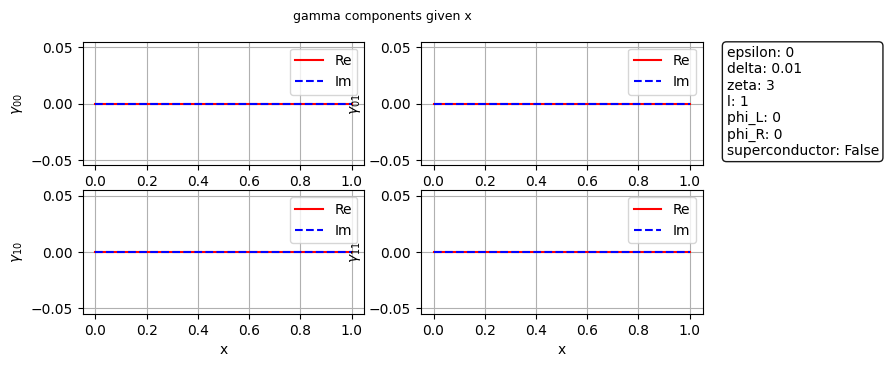

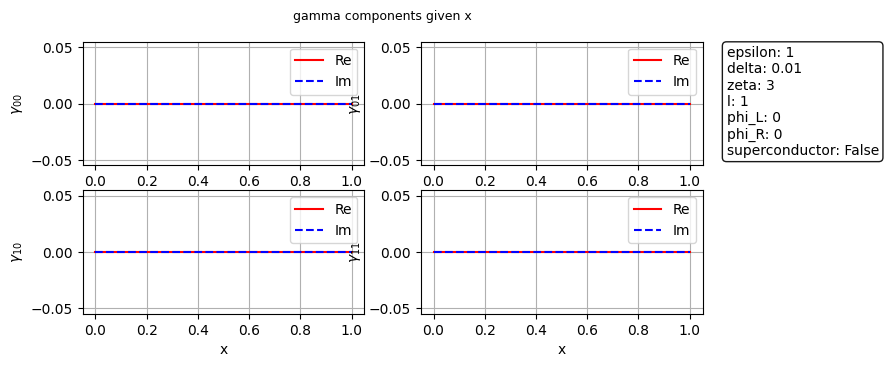

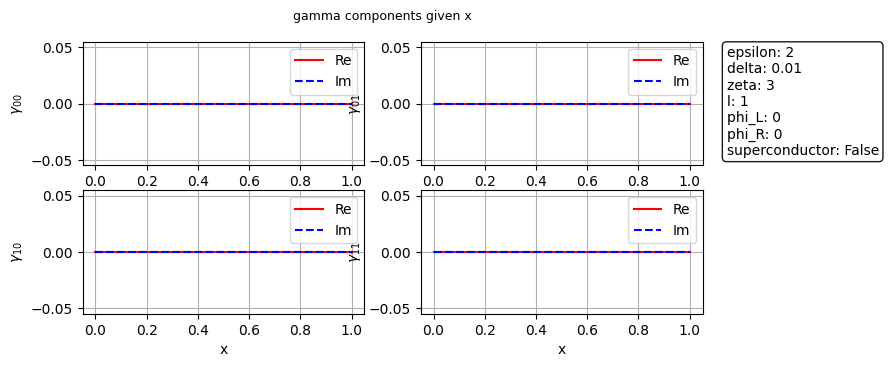

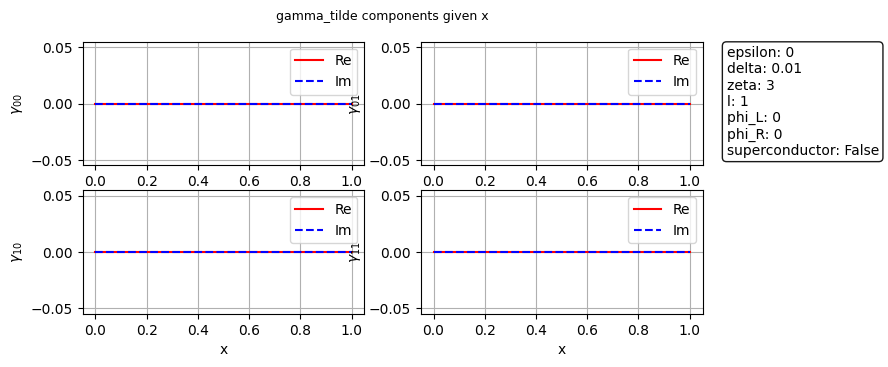

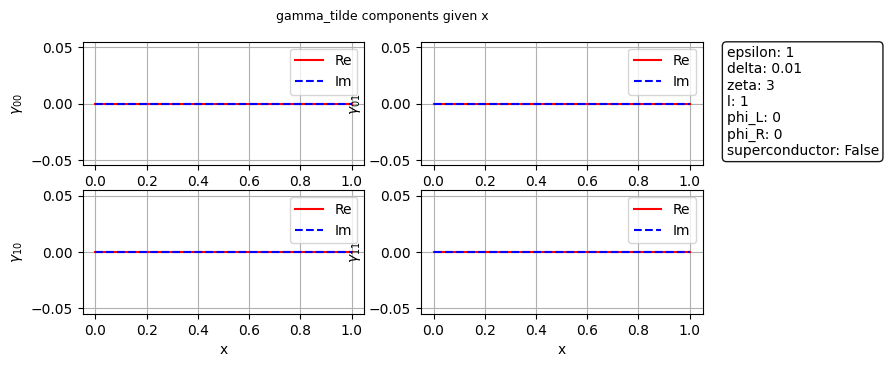

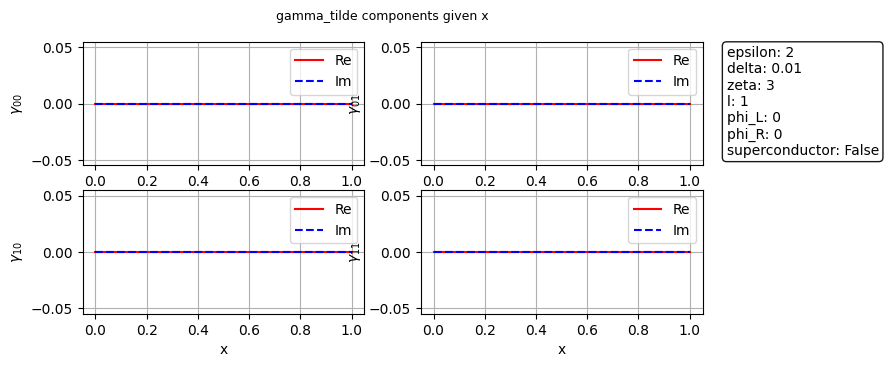

In [15]:
eps_arr_2g = np.array([0, 1, 2])

x = np.linspace(0, l, m)
y = np.zeros((32, m)) 
    
for epsilon in eps_arr_2g:
    plot_usadel_sol(
        x,
        y,
        epsilon,
        delta,
        zeta,
        l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
        matrix_label = 'gamma',
    )

for epsilon in eps_arr_2g:
    plot_usadel_sol(
        x,
        y,
        epsilon,
        delta,
        zeta,
        l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
        matrix_label = 'gamma_tilde',
)

Det er å forvente at løsningen er $\gamma = \tilde{\gamma} = \mathbf{0}$ overalt ettersom at dette er gjettet vårt på løsningen og den oppfyller Usadel-ligningene. Det stemmer overens med det vi finner numerisk.

## h)

In [16]:
def rho_3_fun(matrix_shape: tuple[int, ...] = (2, 2)) -> npt.NDArray[np.complex128]: 
    """Calculates the Pauli-z in nambu space

    Args:
        matrix_shape (tuple[int, ...], optional): shape of I matrix, should always be 2x2 for the pauli matrix. Defaults to (2, 2).

    Returns:
        npt.NDArray[np.complex128]: Pauli-z in nambu space
    """
    I = np.eye(matrix_shape[0], dtype = np.complex128)
    
    return np.block([[I, np.zeros_like(I)], [np.zeros_like(I), -I]])

def green_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
)->  npt.NDArray[np.complex128]:
    """Calculates Green function

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Returns:
        npt.NDArray[np.complex128]: Green function
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)
    single = gamma.ndim == 2

    if single:
        I = np.eye(2, dtype=np.complex128)
        return np.block([
            [2*N - I, bmm(2 * N, gamma)],
            [bmm(-2 * N_tilde, gamma_tilde), -2*N_tilde + I]
        ])
    else:
        N_x = gamma.shape[-1]
        I = np.eye(2, dtype=np.complex128)[..., np.newaxis] * np.ones(N_x)

        first_row = np.concatenate([2*N - I, 2*bmm(N, gamma)], axis=1)
        second_row = np.concatenate([-2*bmm(N_tilde, gamma_tilde), -2*N_tilde + I], axis=1)

        return np.concatenate([first_row, second_row], axis=0)

def dos_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
) -> np.float64 | npt.NDArray[np.float64]:
    """Calculates density of states for Riccati amplitudes

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Returns:
        np.float64: density of states
    """
    rho_3 = rho_3_fun()
    greens = green_fun(gamma, gamma_tilde)

    return np.real(tr(bmm(rho_3, greens))) / 4

Vi introduserer og bruker følgende plot funksjon i senere oppgaver. Vi kunne også brukt den i k) og l), men da får vi ikke samme plots i samme figur, som kan være ønskelig. Vi konkluderte med at en slik modifikasjon på plot_observable funksjonen gjør den unødvendig komplisert og fjerner simpelheten i anvendelse som var formålet. Derfor lagde vi egne scripts der vi ønsket flere plots i samme figur. 


Originalt lagret plot funksjonene plot_observable og plot_usadel til filer, som dere kan se i usadel/plot.py funksjonene i github, vi modifiserte nå til å vise plot i notebooken istedenfor.  Vi får noen feilmeldinger i plot_observable siden den bruker funksjonene current_integrand_fun som blir definert senere i notebooken, men den kjører fortsatt som den skal. Dette var ikke et problem i den originale strukturen, siden alt var definert og impotert fra ulike filer. I notebooken som skulle leveres fikk vi med oss at det var ønskelig at alle oppgaver skulle skrives i riktig rekkefølge, og har derfor definert plottefunksjonen en her, og current_integrand_fun senere, uten at dette blir noe problem for kjøringen.

Det ble brukt LLM CodeX til formatering av tekstboksen i plottene, og dette er markert med

#codex 

kode lagd med CodeX

#codex

In [17]:
def plot_observable(
    observable: Literal['dos', 'current', 'current_integrand'],
    variable_plot: Literal['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R'],
    x: npt.NDArray[np.float64],
    x_index : int,
    y: npt.NDArray[np.float64],
    epsilon: float | npt.NDArray[np.float64],
    delta: float | npt.NDArray[np.float64],
    zeta: float | npt.NDArray[np.float64],
    l: float | npt.NDArray[np.float64],
    phi_L: float | npt.NDArray[np.float64],
    phi_R: float | npt.NDArray[np.float64],
    superconductor: bool,
    figsize: tuple[int, ...] = (8,4),
):
    """Plots observable as function of variable_plot

    Args:
        observable (Literal['dos', 'current', 'current_integrand']): observable to plot
        variable_plot (Literal['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R']): value to plot observable over
        x (npt.NDArray[np.float64]): array to find solution
        x_index (int): index of which to evaluate observable if variable_Plot != 'x'
        location of which to evaluate solution, can be any integer if variable_plot == 'x'
        y (npt.NDARray[np.float64]): initial guess guess
        epsilon (float): quasiparticle excitation energy
        delta (float:) imaginary energy shift
        zeta (float): interface parameter
        l (float): length of normal region
        phi_L (float): left superconducting phase.
        phi_R (float): right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors
        matrix_label (str): which matrix to plot, can be 'gamma', 'gamma_tilde', 'w', 'w_tilde'
        figsize (tuple[int, ...], optional): desired figure size. Defaults to (8,4).

    Raises:
        ValueError: if observable not amongst 'docs', 'current', 'current_integrand'
        ValueError: if variable_plot not amongst 'x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R'
        ValueError: if (variable_plot == 'epsilon') and observable == 'current'
    """
    if observable not in ['dos', 'current', 'current_integrand']:
        raise ValueError("observable must be 'dos', 'current', or 'current_integrand'")
    
    if variable_plot not in ['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R']:
        raise ValueError("variable_plot must be 'x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L' or 'phi_R'")
    
    if variable_plot == 'epsilon' and observable == 'current':
        raise ValueError("variable_plot == 'epsilon' and observable == 'current' is meaningless combination")
    
    variables = {
        'x': x,
        'y': y,
        'epsilon': epsilon,
        'delta': delta,
        'zeta': zeta,
        'l': l,
        'phi_L': phi_L,
        'phi_R': phi_R,
        'superconductor': superconductor
    }
    
    dynamic_var = variables[variable_plot]
    fixed_vars = {k: v for k, v in variables.items() if k!= variable_plot}
    
    if variable_plot == 'x':
        gamma, gamma_tilde, w, w_tilde, _ = usadel_solver(**variables)

        gamma = np.moveaxis(gamma, 0, -1)
        gamma_tilde = np.moveaxis(gamma_tilde, 0, -1)
        w = np.moveaxis(w, 0, -1)
        w_tilde = np.moveaxis(w_tilde, 0, -1)
        
        x_vals = x
        y_vals = np.zeros(len(x), dtype = np.float64)
        
        if observable == 'dos':
            y_vals = dos_fun(gamma, gamma_tilde)
            
        elif observable == 'current_integrand':
            y_vals = current_integrand_fun(gamma, gamma_tilde, w, w_tilde)
        
        elif observable == 'current':
            epsilon_vals = np.linspace(2.0, 0.0, 101)
            integrand_vals = np.zeros((epsilon_vals.size, x.size), dtype = np.float64)         

            y_current = y.copy()
    
            for j, epsilon_val in enumerate(epsilon_vals):
                epsilon_vars = variables | {'epsilon': epsilon_val, 'y': y_current}
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**epsilon_vars)
                    
                y_current = sol
                
                gamma_b = np.moveaxis(gamma, 0, -1)
                gamma_tilde_b = np.moveaxis(gamma_tilde, 0, -1)
                w_b = np.moveaxis(w, 0, -1)
                w_tilde_b = np.moveaxis(w_tilde, 0, -1)
                    
                integrand_vals[j] = current_integrand_fun(
                    gamma_b,
                    gamma_tilde_b,
                    w_b,
                    w_tilde_b
                )
            
            y_vals = - simpson(np.flip(integrand_vals, axis = 0), x = np.flip(epsilon_vals), axis = 0)
            
    else:
        dynamic_vals = np.array(dynamic_var, dtype = np.float64)
            
        x_vals = dynamic_var
        y_vals = np.zeros(len(x_vals), dtype = np.float64)
        
        y_current = y.copy()
        
        for i, value in enumerate(dynamic_vals):
            current_vars = fixed_vars | {variable_plot: value}

            if observable == 'dos':
                if variable_plot == 'epsilon':
                    current_vars['y'] = y_current
                
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**current_vars)
                
                if variable_plot == 'epsilon':
                    y_current = sol
                    
                y_vals[i] = dos_fun(
                    gamma[x_index],
                    gamma_tilde[x_index],
                )
                
            elif observable == 'current_integrand':
                if variable_plot == 'epsilon':
                    current_vars['y'] = y_current
                
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**current_vars)
                
                if variable_plot == 'epsilon':
                    y_current = sol
                
                y_vals[i] = current_integrand_fun(
                    gamma[x_index],
                    gamma_tilde[x_index],
                    w[x_index],
                    w_tilde[x_index]
                )    
                
            elif observable == 'current':
                epsilon_vals = np.linspace(2.0, 0.0, 101)
                integrand_vals = np.zeros_like(epsilon_vals)
                y_current = y.copy()    
                
                for j, epsilon_val in enumerate(epsilon_vals):
                    epsilon_vars = current_vars | {'epsilon': epsilon_val, 'y': y_current}
                    gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**epsilon_vars)
                    
                    y_current = sol
                    
                    integrand_vals[j] = current_integrand_fun(
                        gamma[x_index],
                        gamma_tilde[x_index],
                        w[x_index],
                        w_tilde[x_index]
                    )
                    
                y_vals[i] = -simpson(np.flip(integrand_vals), x = np.flip(epsilon_vals))
                    
    fig, ax = plt.subplots(figsize = figsize)
    ax.plot(x_vals, y_vals)
    
    if variable_plot == 'x':
        ax.set_title(f"{observable} given {variable_plot}")
    else:
        ax.set_title(f"{observable} given {variable_plot} at x_index = {x_index}")
        
    ax.set_xlabel(variable_plot)
    ax.set_ylabel(observable)
    ax.grid()
    
    param_text = '\n'.join(f'{k}: {v}' for k, v in fixed_vars.items() if k not in {'x', 'y'})
    
    #codex
    fig.subplots_adjust(bottom=0.22, top=0.90)
    
    fig.text(
        0.93,
        0.75,
        param_text,
        fontsize = 10,
        va = 'center',
        ha = 'left',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
    )
    #codex
    
    plt.show()

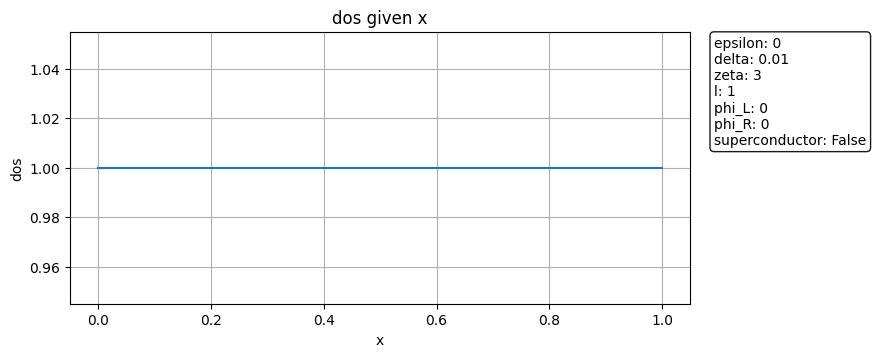

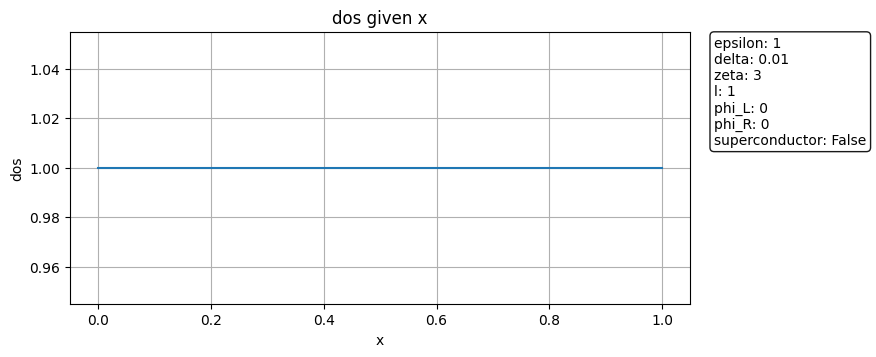

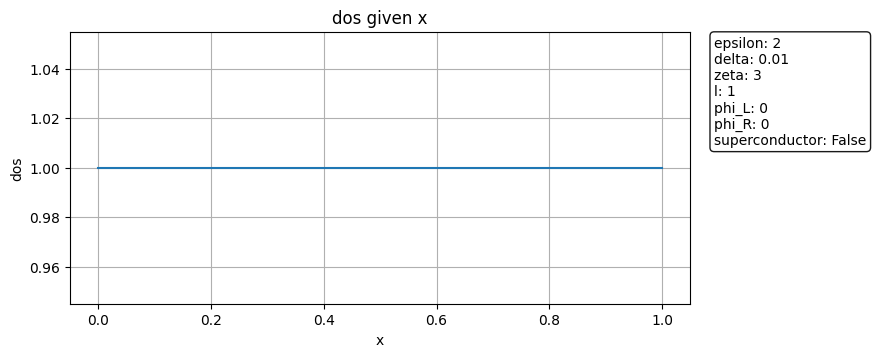

In [18]:
eps_arr_2h = np.array([0, 1, 2])
    
     
for epsilon in eps_arr_2h:
    plot_observable(
        observable = 'dos',
        variable_plot = 'x',
        x = x,
        x_index = -1,
        y = y,
        epsilon = epsilon,
        delta = delta,
        zeta = zeta,
        l = l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
    )

Med null-randbetingelser, $\gamma_L(\varepsilon), \tilde{\gamma}_L(\varepsilon), \gamma_R(\varepsilon), \tilde{\gamma}_R(\varepsilon) = \mathbf{0}$, ettersom $\hat{g} = \hat{\rho}_3$ for disse nullmatrisene, og det følger da eksakt at den dimensjonsløse tilstandstettheten (DOS) er $D/D_0 = 1$ fra ligning (19).



**Dette kan utledes på følgende vis:**

Siden alle deriverte av $\gamma$, $\tilde{\gamma}$, $\omega$ og $\tilde{\omega}$ er proposjonale med $\gamma$, $\tilde{\gamma}$, $\omega$ og $\tilde{\omega}$, og randbetingelsene setter alle disse lik $\mathbf{0}$, blir alle deriverte lik $\mathbf{0}$. Derfor får vi en konstant løsning $\gamma = \mathbf{0}$. Da følger det at

$$
N(x,\varepsilon) = (I - \gamma \tilde{\gamma})^{-1} = I, \qquad
\tilde{N}(x,\varepsilon) = (I - \tilde{\gamma} \gamma)^{-1} = I
$$
Vi ser at g blir forenklet
$$
\hat{g}(x,\varepsilon) =
\begin{pmatrix}
2N - I & 2N\gamma \\
-2\tilde{N}\tilde{\gamma} & -2\tilde{N} + I
\end{pmatrix}
=
\begin{pmatrix}
I & 0 \\
0 & -I
\end{pmatrix}
$$
Summerer opp diagonalene og får tetthet = 1
$$
\hat{\rho}_3 =
\begin{pmatrix}
I & 0 \\
0 & -I
\end{pmatrix}
$$

$$
\hat{\rho}_3 \hat{g} =
\begin{pmatrix}
I & 0 \\
0 & I
\end{pmatrix}
$$

$$
\mathrm{Tr}(\hat{\rho}_3 \hat{g}) = 4
$$

$$
\frac{D(\varepsilon,x)}{D_0}
=
\frac{1}{4}\Re\{\mathrm{Tr}(\hat{\rho}_3 \hat{g})\}
=
1
$$

## j)

In [19]:
def usadel_solver(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Calcualtes the Riccati parameters for given x and y

    Args:
        x (np.NDArray[np.float64]): Array to find solution on
        y (np.NDARray[np.float64]): Initial guess
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        tuple[npt.NDArray[
            np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            ]: Arrays of values for gamma, gamma_tilde, w, w_tilde arrays at all x positions, sol
    """
    solution = solve_bvp(
        make_diff_system(epsilon, delta),
        make_bc(epsilon, delta, zeta, l, phi_L, phi_R, superconductor),
        x, y
    )  
    
    sol = solution.sol(x)
    matrices = vec_to_usadel_matrix(sol)

    gamma_arr = np.moveaxis(matrices[0], -1, 0)
    gamma_tilde_arr = np.moveaxis(matrices[1], -1, 0)
    w_arr = np.moveaxis(matrices[2], -1, 0)
    w_tilde_arr = np.moveaxis(matrices[3], -1, 0)

    return gamma_arr, gamma_tilde_arr, w_arr, w_tilde_arr, sol

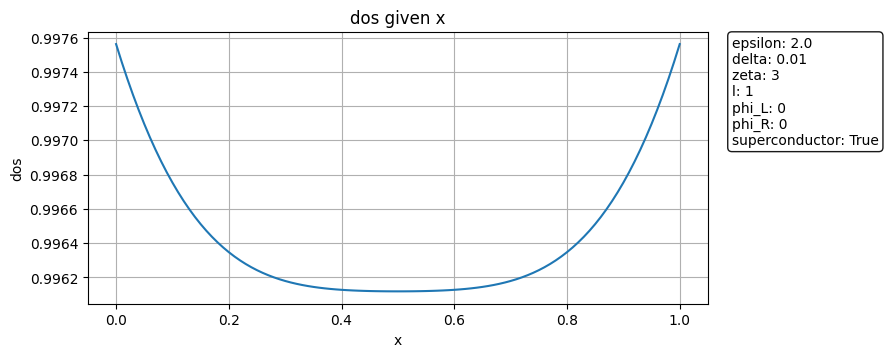

In [20]:
plot_observable(
        observable = 'dos',
        variable_plot = 'x',
        x = x,
        x_index = -1,
        y = y,
        epsilon = 2.0,
        delta = delta,
        zeta = zeta,
        l = l,
        phi_L = 0,
        phi_R = 0,
        superconductor = True,
    )
        

For høye energier ($\epsilon = 2 > \Delta$) forventer vi at tilstandstettheten til det normale metallet vil ligge i nærheten av $D/D_0 = 1$. Siden vi har identiske superledere på hver side av metallet, forventer vi at kurven blir helt symmetrisk om midten. 

I superlederne er tilstandstettheten for $\epsilon=2$ litt større enn 1, ca. 1.15, noe vi sjekket ved å sette $l \ll 1$. Imidlertid blir tilstandstettheten marginalt mindre enn 1 overalt, noe som antagelig skylles proximity-effekten da mange av elektrontilstandene forskyves i energigapet for å danne Cooper-par. Det blir følgelig et underskudd på tilgjengelige tilstander ved høyere energier, som $\epsilon = 2$. Vi observerer at tilstandstettheten i det normale metallet går opp nær grenseflatene, før den faller ned lenger inn i metallområdet.

**Vi kan også prøve å formulere forventningene våre matematisk på følgende vis:**

OpenAI Codex har blitt brukt til LaTeX-formattering her.

Vi starter med å se på størrelsesordenen til diff likning. Noen ledd har mer å si, enn andre ledd. En metode vi kan bruke for å se om løsningen våres gir mening, er ved å forenkle difflikningen, ved å ignorere de ikke linære leddene, siden disse har en del lavere størrelsesorden. 

For å "bevise" dette kan vi bruke Frobenius-normen $\|\cdot\|_F$ for å rekne ut lengden på y. Den blir omtrent 0.3-0.4:

Starter ved å sette inn initialbetingelser
$$
\frac{\sigma}{\varepsilon + i\delta} \approx \frac{\sigma}{2}, \qquad \sigma = \pm 1.
$$


$$
\vartheta_+ \approx \operatorname{atanh}\!\left(\frac12\right), \qquad
\vartheta_- \approx \operatorname{atanh}\!\left(-\frac12\right) = -\vartheta_+.
$$


$$
\vartheta_+ \approx 0.5493.
$$


$$
s_+ = \sinh(0.5493) \approx 0.576, \qquad
c_+ = \cosh(0.5493) \approx 1.154.
$$


$$
s_- = -0.576, \qquad c_- = 1.154.
$$


$$
a = \frac{s_+}{1 + c_+}, \qquad b = \frac{s_-}{1 + c_-}.
$$


$$
1 + c_+ \approx 2.154.
$$


$$
a \approx \frac{0.576}{2.154} \approx 0.267, \qquad
b \approx \frac{-0.576}{2.154} \approx -0.267.
$$


$$
Y =
\begin{pmatrix}
0 & 0.267\\
-0.267 & 0
\end{pmatrix}.
$$


$$
\|Y\|_F
= \sqrt{0^2 + 0.267^2 + (-0.267)^2 + 0^2}
= \sqrt{2\cdot 0.267^2}.
$$


$$
\|Y\|_F \approx \sqrt{0.1426} \approx 0.378.
$$

Hvis vi gjør en litt upresis antagelse om at størrelsesordenen til de tikke linære leddet er lik y^3. siden wFår vi at linær/ikke_linær = 0.1. Som betyr at det linære leddet har omtrent 10 ganger mer og si. 

 $$
\frac{d\omega}{dx}
=
-2i(\varepsilon + i\delta)\,\gamma
\;-\;
2\,\omega\,\tilde N\,\tilde\gamma\,\omega.
$$

$$
-2\,\omega\,\tilde N\,\tilde\gamma\,\omega \;\approx\; Y^{3}.
$$

$$
\frac{\text{ikke-lineært}}{\text{lineært}}
\;\sim\;
\frac{\|\gamma\|_F^{3}}{\|\gamma\|_F}
=
\|\gamma\|_F^{2}
\sim
(0.35)^2
\sim
0.12.
$$

Vi kutter ut det ikke linære leddet. Dette gir oss en simpel 2. ordens diff likning på formen:

$$
\frac{d^{2}\gamma}{dx^{2}} = k^{2}\gamma
\quad\Longrightarrow\quad
\gamma(x) = A e^{kx} + B e^{-kx}.
$$

Dette er cosh som har en liknende form som plottet vi fikk. Når det skal sies er det mange antakelser som er litt halveis lovlige å gjøre, så vi kan ikke bekrefte alt for mye med denne begrunnelsen. 


## k)

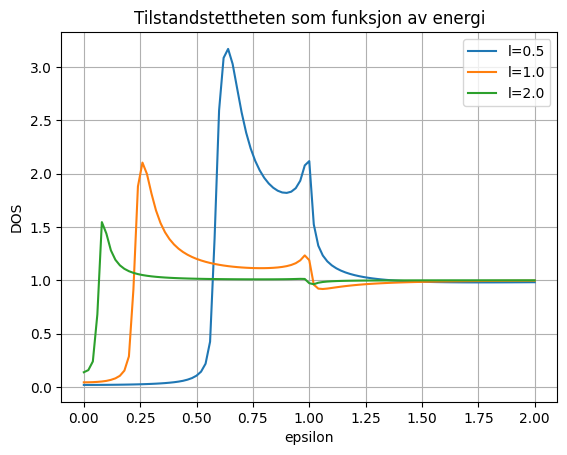

In [21]:
l = 1
m = 101
zeta = 3
delta = 0.01

y = np.zeros((32, m))

l_arr_2k = np.array([0.5, 1, 2])
eps_arr_2k = np.linspace(2, 0, 101)


fig, ax = plt.subplots(1, 1)
    

for l in l_arr_2k:
    x = np.linspace(0, l, m)
    x_index = len(x)//2

    y_vals = np.zeros(len(eps_arr_2k), dtype = np.float64)
    y_current = y.copy()

    for i, epsilon in enumerate(eps_arr_2k): 
        gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(
            x = x,
            y = y_current,
            epsilon = epsilon,
            delta = delta,
            zeta = zeta,
            l = l,
            phi_L = 0,
            phi_R = 0,
            superconductor = True
        )
        y_current = sol
            
        y_vals[i] = dos_fun(
            gamma[x_index],
            gamma_tilde[x_index],
        )

    ax.plot(eps_arr_2k, y_vals, label=f'l={l}')

ax.legend()
ax.grid(True)
ax.set_xlabel('epsilon')
ax.set_ylabel('DOS')
ax.set_title('Tilstandstettheten som funksjon av energi')
plt.show()

Vi observerer at minigapet minker for økende $l$. Her er minigapet intervallet av $\epsilon$-verdier fram til den første toppen. I tillegg observerer vi at toppene blir lavere og bredere for økende $l$, og for $l=2$ er tilstandstettheten nesten flat over mesteparten av energiintervallet, noe som indikerer at de superledende effektene er svakere i et lengre normalt metall på grunn av at proximity-effekten avtar, altså at det er mindre superledende egenskaper som "lekker" inn i det normale metallet.

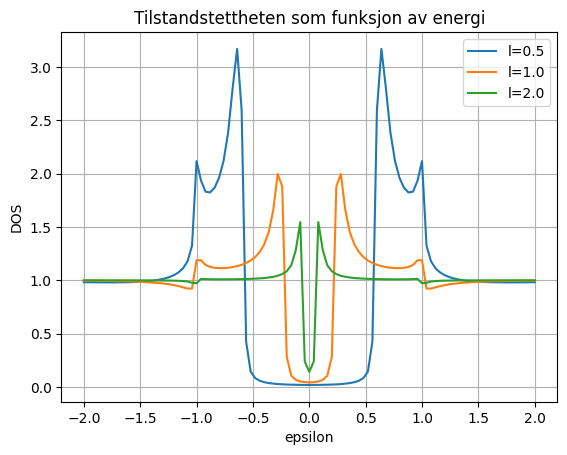

In [22]:
m = 101
zeta = 3
delta = 0.01

y = np.zeros((32, m))

l_arr_2k = np.array([0.5, 1, 2])
eps_arr_2k = np.linspace(2, -2, 101)

fig, ax = plt.subplots(1, 1)  

for l in l_arr_2k:
    x = np.linspace(0, l, m)
    x_index = len(x)//2

    y_vals = np.zeros(len(eps_arr_2k), dtype = np.float64)
    y_current = y.copy()

    for i, epsilon in enumerate(eps_arr_2k): 
        gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(
            x = x,
            y = y_current,
            epsilon = epsilon,
            delta = delta,
            zeta = zeta,
            l = l,
            phi_L = 0,
            phi_R = 0,
            superconductor = True
        )
        y_current = sol
            
        y_vals[i] = dos_fun(
            gamma[x_index],
            gamma_tilde[x_index],
        )

    ax.plot(eps_arr_2k, y_vals, label=f'l={l}')

ax.legend()
ax.grid(True)
ax.set_xlabel('epsilon')
ax.set_ylabel('DOS')
ax.set_title('Tilstandstettheten som funksjon av energi')
plt.show()

Vi ser fra plottet over at når vi speiler de opprinnelige grafene over y-aksen at vi får de gapene vi forventer.

## l)

In [24]:
def green_fun_deriv(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
) -> npt.NDArray[np.complex128]:
    """Calculates the derivative of the Green function

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        npt.NDArray[np.complex128]: d_x g
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)
    d_N, d_N_tilde = N_deriv_fun(gamma, gamma_tilde, w, w_tilde)
    single = gamma.ndim == 2

    if single:
        return 2 * np.block([
            [d_N, bmm(N, w) + bmm(d_N, gamma)],
            [-bmm(N_tilde, w_tilde) - bmm(d_N_tilde, gamma_tilde), -d_N_tilde]
        ])
    else:
        first_row = np.concatenate([2*d_N, 2*(bmm(N, w) + bmm(d_N, gamma))], axis=1)
        second_row = np.concatenate([
            -2*(bmm(N_tilde, w_tilde) + bmm(d_N_tilde, gamma_tilde)),
            -2*d_N_tilde
        ], axis=1)

        return np.concatenate([first_row, second_row], axis=0)

def current_integrand_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
) -> np.float64 | npt.NDArray[np.float64]:
    """Calculates the current integrand

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        np.float64: current integrand
    """
    rho_3 = rho_3_fun()
    greens = green_fun(gamma, gamma_tilde)
    d_greens = green_fun_deriv(gamma, gamma_tilde, w, w_tilde)
    commutator = bmm(greens, d_greens) - bmm(d_greens, greens)
    
    return np.real(tr(bmm(rho_3, commutator)))

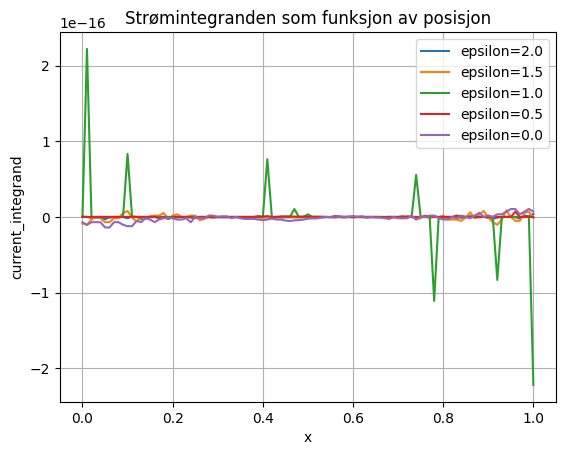

In [25]:
l = 1
m = 101
zeta = 3
delta = 0.01

x = np.linspace(0, l, m)
y = np.zeros((32, m))
epsilon_arr_2l = np.array([2, 1.5, 1.0, 0.5, 0.0])

fig, ax = plt.subplots(1, 1)
    
for epsilon in epsilon_arr_2l:
    gamma, gamma_tilde, w, w_tilde, _ = usadel_solver(
        x = x,
        y = y,
        epsilon = epsilon,
        delta = delta,
        zeta = zeta,
        l = l,
        phi_L = 0,
        phi_R = 0,
        superconductor = True
    )

    gamma = np.moveaxis(gamma, 0, -1)
    gamma_tilde = np.moveaxis(gamma_tilde, 0, -1)
    w = np.moveaxis(w, 0, -1)
    w_tilde = np.moveaxis(w_tilde, 0, -1)

    x_vals = x.copy()
    y_vals = current_integrand_fun(gamma, gamma_tilde, w, w_tilde)

    ax.plot(x_vals, y_vals, label=f'epsilon={epsilon}')

ax.legend()
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('current_integrand')
ax.set_title('Strømintegranden som funksjon av posisjon')
plt.show()

Vi observerer at strømintegrandanten er tilnærmet lik null for alle energiverdier, som er fysisk forventet siden det ikke er noen faseforskjell mellom de to superlederne ($\phi_L= \phi_R=0$). Avvikene fra null er på størrelsesorden fra og med $10^{-14}$ til og med $10^{-18}$, som tilsier at det både er numerisk støy fra `solve_bvp` og støy tilknyttet avrundingsfeil i flyttallsaritmetikk som følge av maskinpresisjon. Siden feilen er så liten ser vi vekk i fra den.

## m)

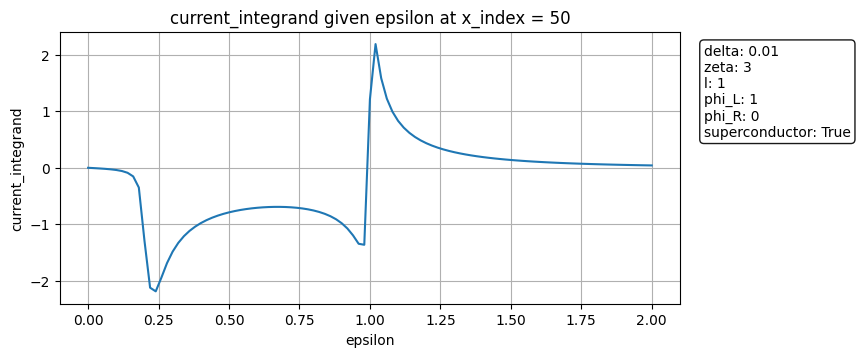

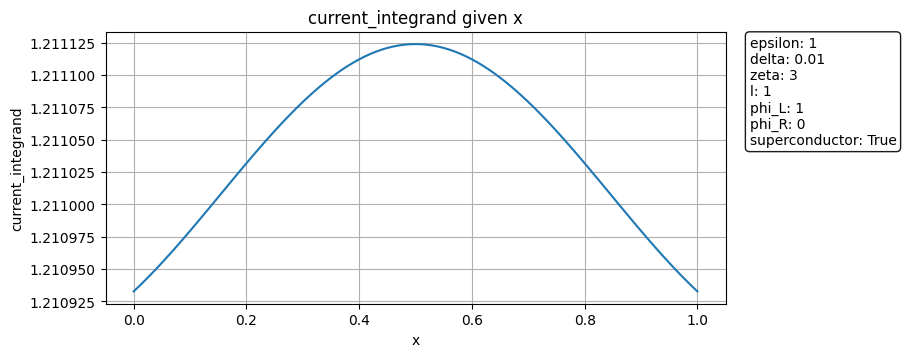

In [39]:
epsilon_arr = np.linspace(2, 0, 101)
x_index = len(x)//2
    
plot_observable(
    observable = 'current_integrand',
    variable_plot = 'epsilon',
    x = x,
    x_index = x_index,
    y = y,
    epsilon = epsilon_arr,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = 1,
    phi_R = 0,
    superconductor = True,
)

plot_observable(
    observable = 'current_integrand',
    variable_plot = 'x',
    x = x,
    x_index = 0,
    y = y,
    epsilon = 1,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = 1,
    phi_R = 0,
    superconductor = True,
)

Til forskjell fra oppgave 2l er det nå en ikke-null strømintegrand på grunn av faseforskjellen $\Delta \phi$. Denne går gjennom det normale metallet mellom de to superlederne. Fra første plott ser vi at strømintegranden i midten av metallet først er negativ deretter positiv. Vi observerer at grafen til strømintegranden har kvalitativt like karakteristikker som grafen av tilstandstetthet for samme lengde $l$, som viser at det er en korrelasjon mellom disse størrelsene.

Vi ser av andre plott at strømintegranden er tilnærmet konservert som funksjon av posisjon. Antagelig er det numerisk støy da feilen er på størrelsesorden $10^{-3}$.

## n)

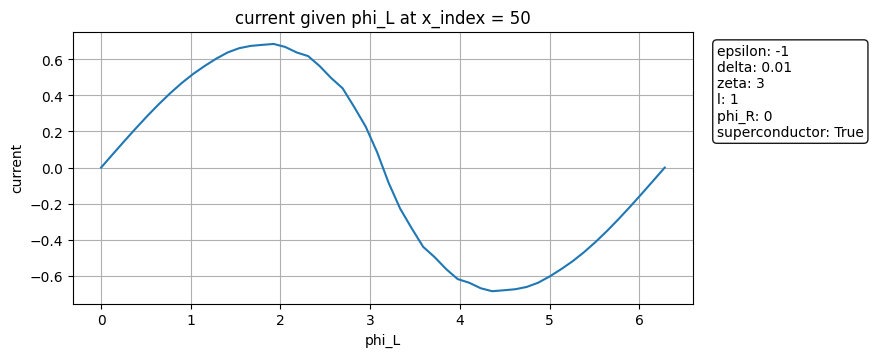

In [40]:
phi_L_arr_2n = np.linspace(0, 2 * np.pi, 50) #update to contain more points after optimizing runtime
x_index = len(x)//2
    
plot_observable(
    observable = 'current',
    variable_plot = 'phi_L',
    x = x,
    x_index = x_index,
    y = y,
    epsilon = -1,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = phi_L_arr_2n,
    phi_R = 0,
    superconductor = True,
)

For å løse denne oppgaven setter vi $\phi_R = 0$ slik at $\Delta \phi = \phi_L \in [0, 2\pi]$, hvor vi har valgt 50 jevnt fordelt verdier av $\phi_L$ på det intervallet. Strømmen beregnes for $\epsilon \in [0, 2]$.

Fra plotting av den dimensjonsløse strømmen $I/I_0$ i midten av det normale metallet ser vi at strømmen oppfører seg som en sinusfunksjon av faseforskjellen, altså $I \sim \sin(\Delta \phi) = \sin(\phi_L)$, men det bør presiseres at den er litt avvikende fra en ren sinusfunksjon.